# **Conhecendo os dados**

**Importar a base**

In [74]:
import pandas as pd
import urllib.request

url = "https://github.com/luizamb2306/custos_plano_de_saude/raw/refs/heads/main/base_plano_de_saude.xlsx"

urllib.request.urlretrieve(url, "custos_plano_de_saude.xlsx")

dados = pd.read_excel(
    "custos_plano_de_saude.xlsx",
    sheet_name="base"
)

print(dados)

      Idade       Sexo     IMC  Qte_Filhos Fumante    Região  Custo_Saude
0        19   Feminino  27.900           0     Sim    Centro  1688.492400
1        18  Masculino  33.770           1     Não   Sudeste   172.555230
2        28  Masculino  33.000           3     Não   Sudeste   444.946200
3        33  Masculino  22.705           0     Não     Norte  2198.447061
4        32  Masculino  28.880           0     Não     Norte   386.685520
...     ...        ...     ...         ...     ...       ...          ...
1333     50  Masculino  30.970           3     Não     Norte  1060.054830
1334     18   Feminino  31.920           0     Não  Nordeste   220.598080
1335     18   Feminino  36.850           0     Não   Sudeste   162.983350
1336     21   Feminino  25.800           0     Não    Centro   200.794500
1337     61   Feminino  29.070           0     Sim     Norte  2914.136030

[1338 rows x 7 columns]


**Identificar todas as colunas disponíveis**

In [75]:
df = dados

print(df.head())
print(df.columns)

   Idade       Sexo     IMC  Qte_Filhos Fumante   Região  Custo_Saude
0     19   Feminino  27.900           0     Sim   Centro  1688.492400
1     18  Masculino  33.770           1     Não  Sudeste   172.555230
2     28  Masculino  33.000           3     Não  Sudeste   444.946200
3     33  Masculino  22.705           0     Não    Norte  2198.447061
4     32  Masculino  28.880           0     Não    Norte   386.685520
Index(['Idade', 'Sexo', 'IMC', 'Qte_Filhos', 'Fumante', 'Região',
       'Custo_Saude'],
      dtype='object')


**Validação dos dados**

In [76]:
def resumo(df, coluna):

    nulos = df[coluna].isna().sum()
    unicos = df[coluna].nunique()
    tipo = df[coluna].dtype

    if tipo != "object":  # se a coluna for numérica

        max = df[coluna].max()
        min = df[coluna].min()

        q1 = df[coluna].quantile(0.25)
        q3 = df[coluna].quantile(0.75)

        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        outliers_inferiores = (df[coluna] < limite_inferior).sum()
        outliers_superiores = (df[coluna] > limite_superior).sum()

    else:
        max = None
        min = None
        q1 = None
        q3 = None
        limite_inferior = None
        limite_superior = None
        outliers_inferiores = None
        outliers_superiores = None

    # colocando resultados em um dict
    resumo = {
        "coluna": [coluna],
        "unicos": [unicos],
        "nulos": [nulos],
        "max": [max],
        "min": [min],
        "Q1": [q1],
        "Q3": [q3],
        "lim_inf": [limite_inferior],
        "lim_sup": [limite_superior],
        "outliers_inf": [outliers_inferiores],
        "outliers_sup": [outliers_superiores],
        "tipo": [tipo]
    }

    resumo_df = pd.DataFrame(resumo)

    return resumo_df

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

# transformar tudo em dataframe
output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')


╒════╤═════════════╤══════════╤═════════╤═════════╤═════════╤══════════╤═══════════╤═══════════╤═══════════╤════════════════╤════════════════╤═════════╕
│    │ coluna      │   unicos │   nulos │     max │     min │       Q1 │        Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo    │
╞════╪═════════════╪══════════╪═════════╪═════════╪═════════╪══════════╪═══════════╪═══════════╪═══════════╪════════════════╪════════════════╪═════════╡
│  0 │ Idade       │       47 │       0 │   64    │  18     │  27      │   51      │     -9    │     87    │              0 │              0 │ int64   │
├────┼─────────────┼──────────┼─────────┼─────────┼─────────┼──────────┼───────────┼───────────┼───────────┼────────────────┼────────────────┼─────────┤
│  1 │ Sexo        │        2 │       0 │  nan    │ nan     │ nan      │  nan      │    nan    │    nan    │                │                │ object  │
├────┼─────────────┼──────────┼─────────┼─────────┼─────────┼──────────┼──────────

/tmp/ipykernel_414/3930680207.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


# **Tratamento dos dados**

In [77]:
#criando variaveis dummy

df['fumante_dummy'] = (df['Fumante'] == 'Sim').astype(int)
df['sexo_dummy'] = (df['Sexo'] == 'Feminino').astype(int)

#para região, a variável de referencia será Centro
df['sudeste_dummy'] = (df['Região'] == 'Sudeste').astype(int)
df['norte_dummy'] = (df['Região'] == 'Norte').astype(int)
df['nordeste_dummy'] = (df['Região'] == 'Nordeste').astype(int)

print(df)
print(df.columns)

      Idade       Sexo     IMC  Qte_Filhos Fumante    Região  Custo_Saude  \
0        19   Feminino  27.900           0     Sim    Centro  1688.492400   
1        18  Masculino  33.770           1     Não   Sudeste   172.555230   
2        28  Masculino  33.000           3     Não   Sudeste   444.946200   
3        33  Masculino  22.705           0     Não     Norte  2198.447061   
4        32  Masculino  28.880           0     Não     Norte   386.685520   
...     ...        ...     ...         ...     ...       ...          ...   
1333     50  Masculino  30.970           3     Não     Norte  1060.054830   
1334     18   Feminino  31.920           0     Não  Nordeste   220.598080   
1335     18   Feminino  36.850           0     Não   Sudeste   162.983350   
1336     21   Feminino  25.800           0     Não    Centro   200.794500   
1337     61   Feminino  29.070           0     Sim     Norte  2914.136030   

      fumante_dummy  sexo_dummy  sudeste_dummy  norte_dummy  nordeste_dummy

In [78]:
#Rodando mapeamento inicial novamente para verificar se houveram grandes mudanças
#após o tratamento de dados

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

# transformar tudo em dataframe
output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

╒════╤════════════════╤══════════╤═════════╤═════════╤═════════╤══════════╤═══════════╤═══════════╤═══════════╤════════════════╤════════════════╤═════════╕
│    │ coluna         │   unicos │   nulos │     max │     min │       Q1 │        Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo    │
╞════╪════════════════╪══════════╪═════════╪═════════╪═════════╪══════════╪═══════════╪═══════════╪═══════════╪════════════════╪════════════════╪═════════╡
│  0 │ Idade          │       47 │       0 │   64    │  18     │  27      │   51      │     -9    │     87    │              0 │              0 │ int64   │
├────┼────────────────┼──────────┼─────────┼─────────┼─────────┼──────────┼───────────┼───────────┼───────────┼────────────────┼────────────────┼─────────┤
│  1 │ Sexo           │        2 │       0 │  nan    │ nan     │ nan      │  nan      │    nan    │    nan    │                │                │ object  │
├────┼────────────────┼──────────┼─────────┼─────────┼─────────┼

/tmp/ipykernel_414/4189664864.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


# **EDA - Univariada**

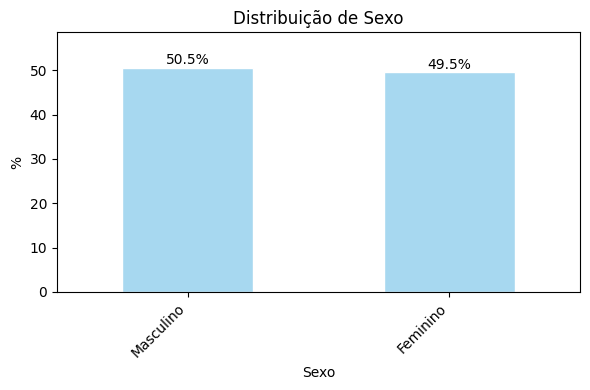

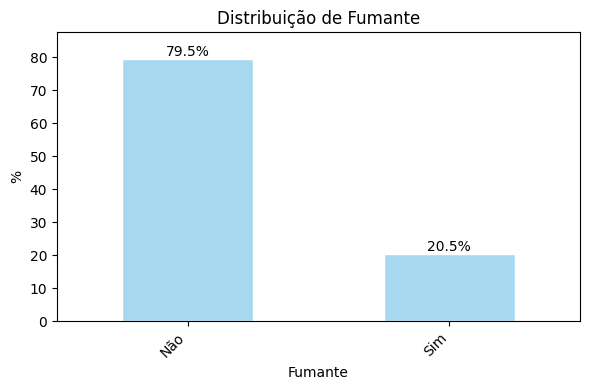

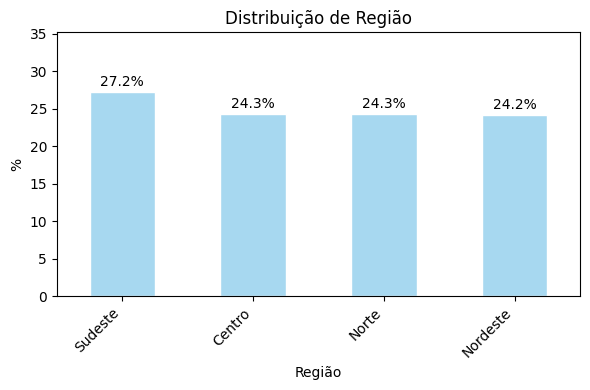

In [79]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt

#dados de interesse:
quali = ['Sexo', 'Fumante', 'Região' ]

def eda_qualitativos (df,coluna):
  freq = df[coluna].value_counts()/len(df)*100
  return freq

# loop para gerar um gráfico para cada variável
for coluna in quali:

    analise = eda_qualitativos(df, coluna)

    plt.figure(figsize=(6,4))

    ax = analise.plot(
        kind='bar',
        color='#A7D8F0',      # azul bebê
        edgecolor='white'     # borda branca
    )

    plt.title(f'Distribuição de {coluna}')

    plt.ylabel('%')

    plt.ylim(0, analise.max() + 8)

    # adiciona rótulos em cima das barras
    for i, valor in enumerate(analise):

        plt.text(
            i,                # posição horizontal
            valor + 0.8,      # posição vertical
            f'{valor:.1f}%',  # texto exibido
            ha='center'       # alinhamento horizontal
        )

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

    plt.close()



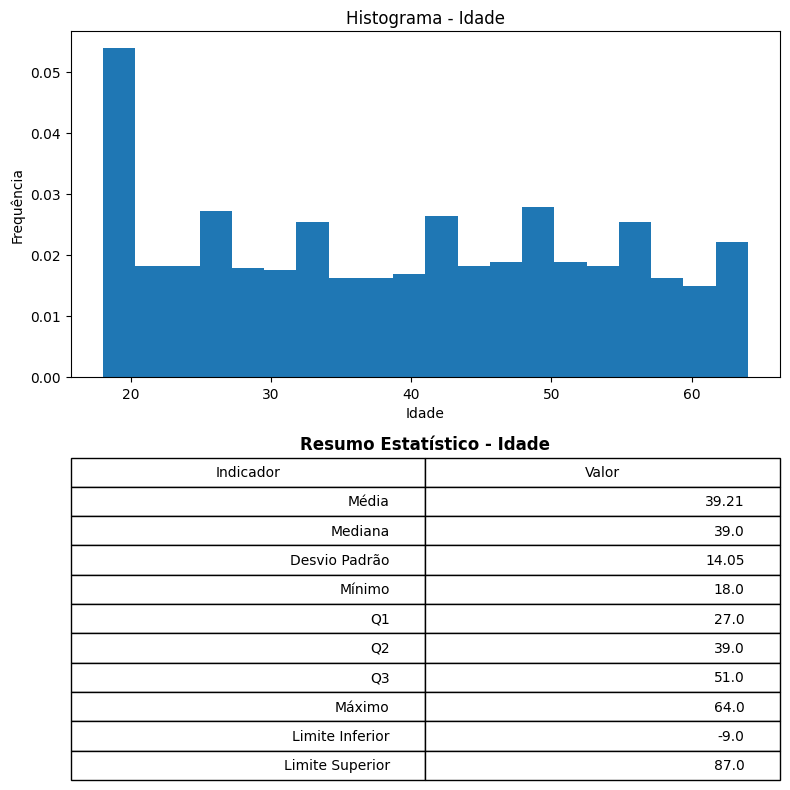

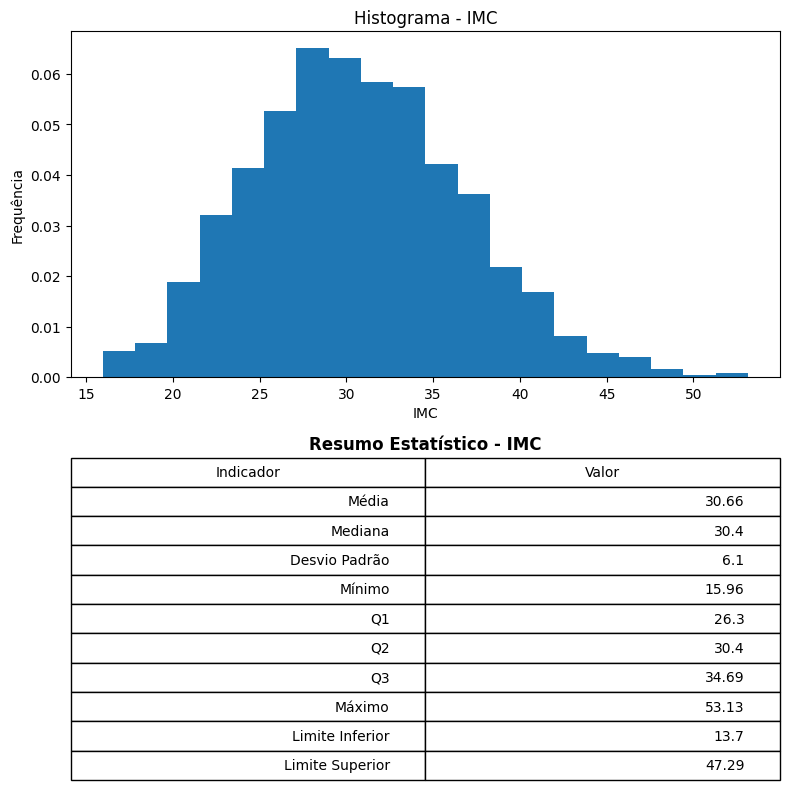

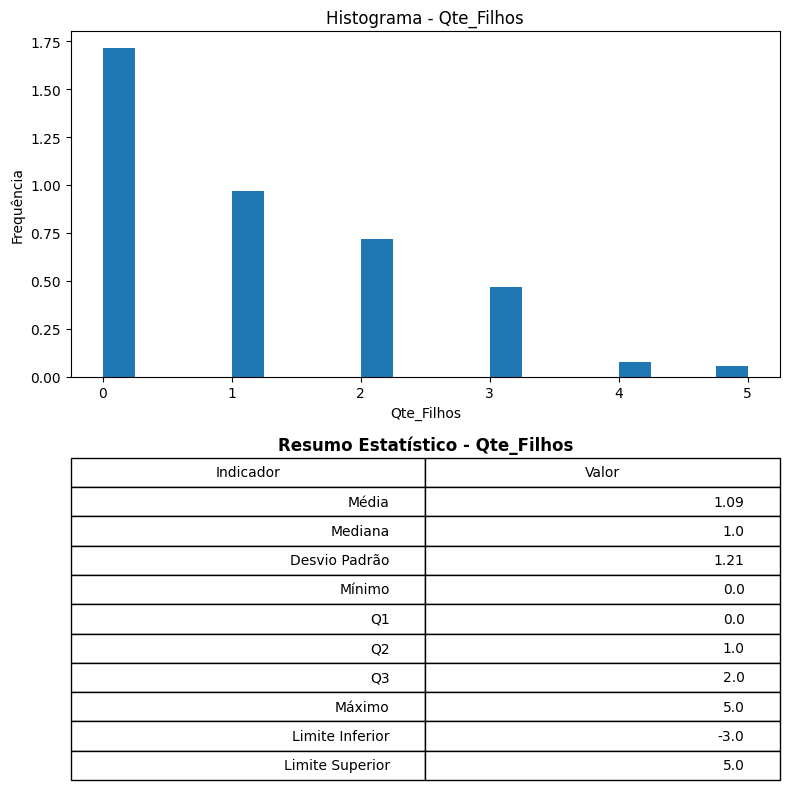

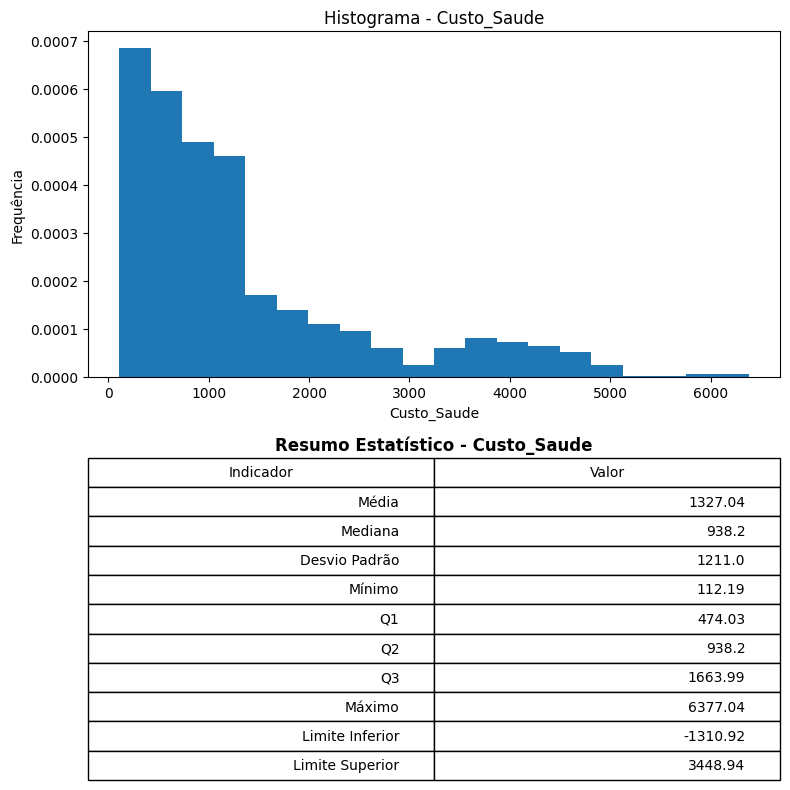

In [80]:
#ANALISE DOS DADOS QUANTITATIVOS
quanti = ['Idade', 'IMC', 'Qte_Filhos', 'Custo_Saude']

def eda_quanti(df, coluna):

    media = df[coluna].mean()
    mediana = df[coluna].median()
    desvio = df[coluna].std()

    minimo = df[coluna].min()
    maximo = df[coluna].max()

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.5)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    resumo = {
        'Média': media,
        'Mediana': mediana,
        'Desvio Padrão': desvio,
        'Mínimo': minimo,
        'Q1': q1,
        'Q2': q2,
        'Q3': q3,
        'Máximo': maximo,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior
    }

    return resumo

for coluna in quanti:

  resumo = eda_quanti(df, coluna)

  # FIGURA

  fig, ax = plt.subplots(
      2, 1,
      figsize=(8,8),
      gridspec_kw={'height_ratios': [2,1.8]}
  )

  # HISTOGRAMA

  ax[0].hist(
      df[coluna].dropna(),
      bins=20,
      density = True
  )

  ax[0].set_title(f'Histograma - {coluna}')
  ax[0].set_xlabel(coluna)
  ax[0].set_ylabel('Frequência')

  # remove notação científica
  ax[0].ticklabel_format(style='plain', axis='x')

  # TABELA RESUMO

  tabela_resumo = pd.DataFrame(
      resumo.items(),
      columns=['Indicador', 'Valor']
  )

  tabela_resumo['Valor'] = tabela_resumo['Valor'].round(2)

  ax[1].axis('off')

  ax[1].set_title(
      f'Resumo Estatístico - {coluna}',
      fontsize=12,
      fontweight='bold',
      pad=10
  )

  tabela = ax[1].table(
      cellText=tabela_resumo.values,
      colLabels=tabela_resumo.columns,
      loc='center'
  )

  tabela.auto_set_font_size(False)
  tabela.set_fontsize(10)
  tabela.scale(1, 1.5)

  plt.tight_layout()

  plt.show()

  plt.close()


# **EDA Bivariada - Qualitativo x Quantitativo**



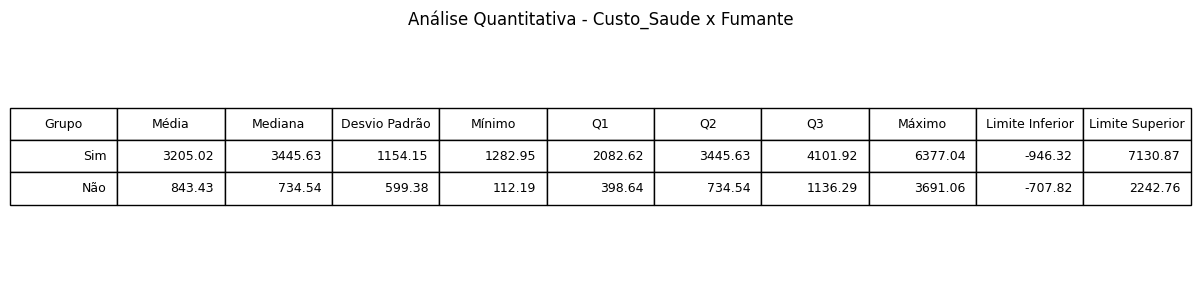

In [81]:
#dados qualitativos X quantitativos

#fumante x custo_saude

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

target = 'Fumante'

quanti = ['Custo_Saude']

for coluna in quanti:

    # lista para armazenar resultados
    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)


    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)

    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


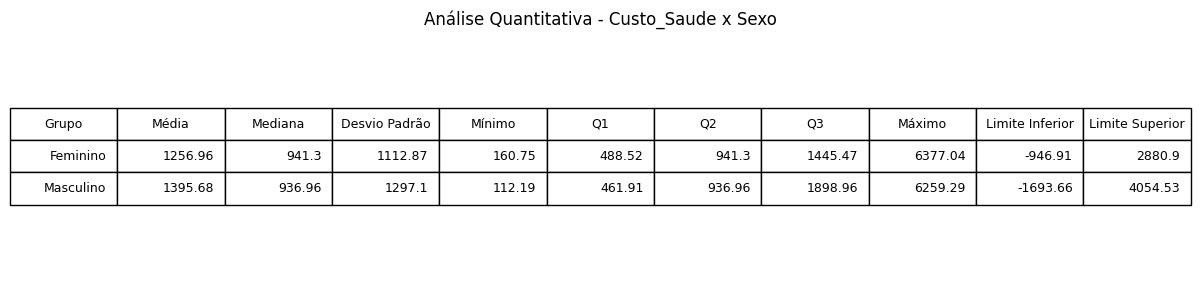

In [82]:
#dados qualitativos X quantitativos
#sexo x custo_saude

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

target = 'Sexo'

quanti = ['Custo_Saude']

for coluna in quanti:

    # lista para armazenar resultados
    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)


    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


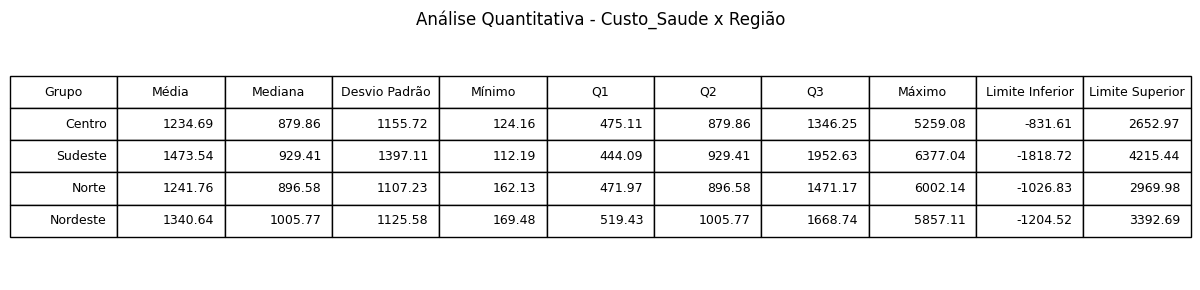

In [83]:
#dados qualitativos X quantitativos

#região x custo saude

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

target = 'Região'

quanti = ['Custo_Saude']

for coluna in quanti:

    # lista para armazenar resultados
    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)


    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


# **EDA Bivariada - Coeficiente de determinação**

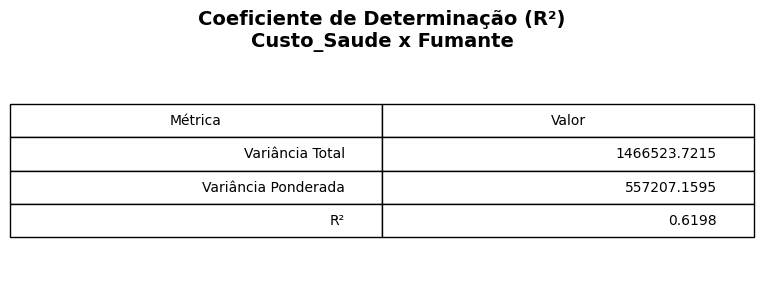

In [84]:
#busca verificar quanto da variancia total é explicada pela introdução da variavel qualitativa

#fumante x custo saude
x = 'Fumante'

quanti = ['Custo_Saude']


def coef_determinacao(df, qualitativa, quantitativa):

    dados = df[[qualitativa, quantitativa]].dropna()

    media_geral = dados[quantitativa].mean()

    # Soma total dos quadrados
    SST = (
        (dados[quantitativa] - media_geral) ** 2
    ).sum()

    # Soma dos quadrados dentro dos grupos
    medias_grupos = (
        dados.groupby(qualitativa)[quantitativa]
        .transform('mean')
    )

    SSW = (
        (dados[quantitativa] - medias_grupos) ** 2
    ).sum()

    # R² / Eta²
    r2 = 1 - (SSW / SST)

    # Variância total
    var_total = dados[quantitativa].var()

    # Variância intra-grupos equivalente
    var_ponderada = SSW / len(dados)

    return r2, var_total, var_ponderada


for y in quanti:

    # calcular métricas
    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


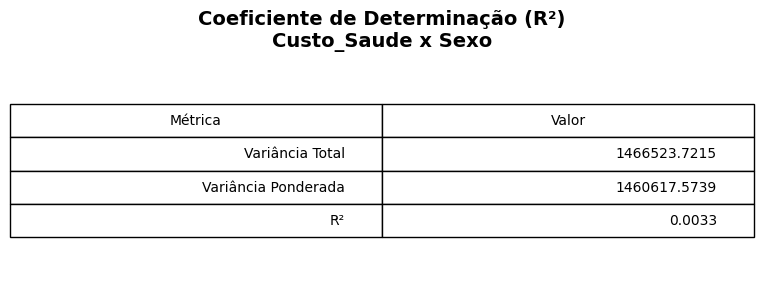

In [85]:
#Sexo x custo saude
x = 'Sexo'

for y in quanti:

    # calcular métricas
    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


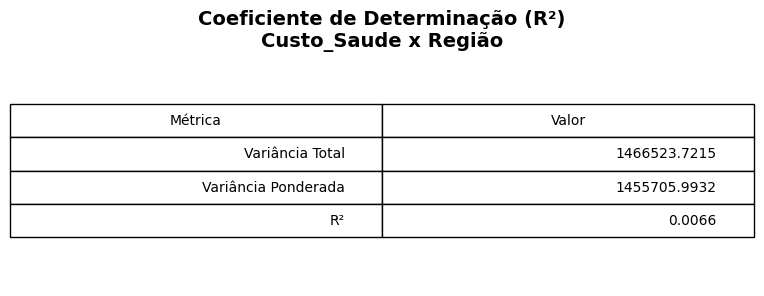

In [86]:
#Região x custo saude
x = 'Região'

for y in quanti:

    # calcular métricas
    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


# **EDA Bivariada - Dados quantitativos**

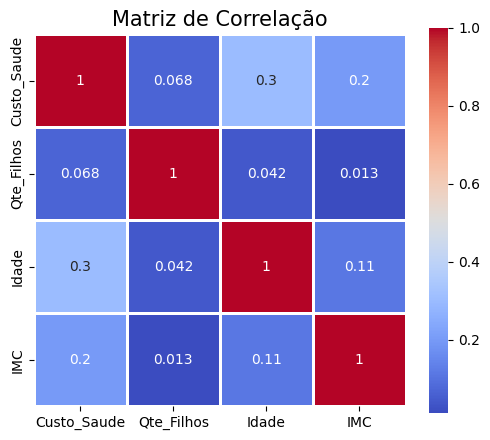

In [87]:
#dados quantitativos

# IMC x Custo_Saude
# Qte_filhos x Custo_Saude
# Idade x Custo_Saude

import matplotlib.pyplot as plt
import seaborn as sns

dado_1 = 'Custo_Saude'
dado_2 = 'Qte_Filhos'
dado_3 = 'Idade'
dado_4 = 'IMC'


data = df[[dado_1, dado_2, dado_3, dado_4]]

correlacao = data.corr()

#CRIAR O HEATMAP

plt.figure(figsize=(6,5))

sns.heatmap(
    correlacao,          # matriz de correlação
    annot=True,          # escreve os valores nas células
    cmap="coolwarm",     # paleta de cores
    linewidths=1,        # linhas entre as células
    square=True          # células quadradas
)

plt.title("Matriz de Correlação", fontsize=15)

plt.show()

plt.close()

# **Regressão Linear Multipla - Desenvolvimentos**

Parâmetros estimados:
[-1302.99039269  2384.85345419    25.68563525    33.91934536
    13.13143594    -7.49710581    60.70870919    96.00509913
    47.55005451]

Modelo estimado:
Ŷ = -1302.990 + 2384.853X₁ + 25.686X₂ + 33.919X₃ + 13.131X₄ + -7.497X₅ + 60.709X₆ + 96.005X₇ + 47.550X₈

R² = 0.751
R² ajustado = 0.749


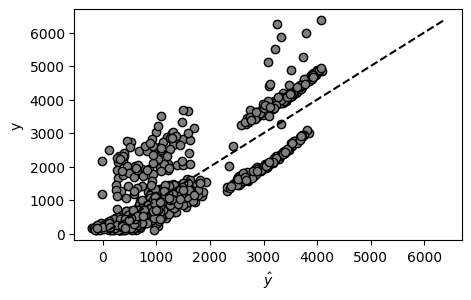

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:24:12   Log-Likelihood:                -10467.
No. Observations:                1338   AIC:                         2.095e+04
Df Residuals:                    1329   BIC:                         2.100e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1302.9904    103.297    -12.614      0.0

In [88]:
#rodando o primeiro modelo

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera


# ENTRADA DOS DADOS

['Idade', 'Sexo', 'IMC', 'Qte_Filhos', 'Fumante', 'Região',
       'Custo_Saude', 'fumante_dummy', 'sexo_dummy', 'sudeste_dummy',
       'norte_dummy', 'nordeste_dummy']


# Variáveis explicativas
x1 = np.array(df['fumante_dummy'])
x2 = np.array(df['Idade'])
x3 = np.array(df['IMC'])
x4 = np.array(df['sexo_dummy'])
x5 = np.array(df['sudeste_dummy'])
x6 = np.array(df['norte_dummy'])
x7 = np.array(df['nordeste_dummy'])
x8 = np.array(df['Qte_Filhos'])

# Variável resposta
y = np.array(df['Custo_Saude'])


# CRIA A COLUNA DO INTERCEPTO
# Coluna de 1's usada para estimar θ₀

x0 = np.ones(len(x1))

# CRIA A MATRIZ X

X = np.hstack((
    x0.reshape(-1, 1),
    x1.reshape(-1, 1),
    x2.reshape(-1, 1),
    x3.reshape(-1, 1),
    x4.reshape(-1, 1),
    x5.reshape(-1, 1),
    x6.reshape(-1, 1),
    x7.reshape(-1, 1),
    x8.reshape(-1, 1),
))

# AJUSTA O MODELO OLS

model = sm.OLS(y, X)

# .fit() estima os parâmetros
model_adjusted = model.fit()

# CALCULA OS VALORES ESTIMADOS

y_pred = model_adjusted.predict(X)

# MOSTRA OS PARÂMETROS

print("Parâmetros estimados:")
print(model_adjusted.params)

# MOSTRA O MODELO ESTIMADO

print("\nModelo estimado:")

print(
    f"Ŷ = {model_adjusted.params[0]:.3f} "
    f"+ {model_adjusted.params[1]:.3f}X₁ "
    f"+ {model_adjusted.params[2]:.3f}X₂ "
    f"+ {model_adjusted.params[3]:.3f}X₃ "
    f"+ {model_adjusted.params[4]:.3f}X₄ "
    f"+ {model_adjusted.params[5]:.3f}X₅ "
    f"+ {model_adjusted.params[6]:.3f}X₆ "
    f"+ {model_adjusted.params[7]:.3f}X₇ "
    f"+ {model_adjusted.params[8]:.3f}X₈"
)

# R²:

print(f"\nR² = {model_adjusted.rsquared:.3f}")

# R² ajustado:

print(f"R² ajustado = {model_adjusted.rsquared_adj:.3f}")

# GRÁFICO: Y ESTIMADO × Y OBSERVADO

plt.figure(figsize=(5, 3))

plt.plot(
    y_pred,
    y,
    'o',
    color='gray',
    markersize=6,
    markerfacecolor='gray',
    markeredgecolor='black'
)

# Linha y = ŷ
xy = np.arange(
    np.min(y),
    np.max(y),
    0.1
)

plt.plot(
    xy,
    xy,
    color='black',
    linestyle='--'
)

plt.xlabel(r"$\hat{y}$")
plt.ylabel("y")

plt.show()

# RESUMO ESTATÍSTICO E DIAGNÓSTICOS DO MODELO

print(model_adjusted.summary())

# MULTICOLINEARIDADE — VIF

vif = []

for i in range(1, X.shape[1]):
    vif.append(
        variance_inflation_factor(X, i)
    )

print("\n--- Multicolinearidade (VIF) ---")

for i, valor in enumerate(vif, start=1):
    print(f"X{i}: VIF = {valor:.3f}")


# HOMOCEDASTICIDADE — TESTE DE BREUSCH-PAGAN

bp = het_breuschpagan(
    model_adjusted.resid,
    model_adjusted.model.exog
)

bp_lm_stat = bp[0]
bp_lm_pvalue = bp[1]

print("\n--- Homocedasticidade (Breusch-Pagan) ---")
print(f"Estatística LM: {bp_lm_stat:.3f}")
print(f"p-valor: {bp_lm_pvalue:.3f}")

#Dada a existência da heterocedasticidade, corrigindo o erro padrão calculado dos
#parâmetros para o erro padrão robusto, a fim de realizar inferências válidas

# HC3 = estimador de erro-padrão robusto à heterocedasticidade

model_robusto = model_adjusted.get_robustcov_results(
    cov_type='HC3',
    use_t=True
)

print("\n--- Inferência robusta à heterocedasticidade ---")

print("Coeficiente     Erro-padrão     t       p-valor")

for i in range(len(model_robusto.params)):

    coef = model_robusto.params[i]
    erro_padrao = model_robusto.bse[i]
    t = model_robusto.tvalues[i]
    p_valor = model_robusto.pvalues[i]

    print(
        f"{coef:10.3f}     "
        f"{erro_padrao:10.3f}     "
        f"{t:7.3f}     "
        f"{p_valor:.4f}"
    )

# IC de 95% para cada β

ic_robusto = model_robusto.conf_int(alpha=0.05)

print("\n--- Intervalo de confiança robusto (95%) ---")

for i in range(len(model_robusto.params)):

    coef = model_robusto.params[i]
    limite_inferior = ic_robusto[i, 0]
    limite_superior = ic_robusto[i, 1]

    print(
        f"β{i}: "
        f"estimativa = {coef:.3f} | "
        f"IC95% = [{limite_inferior:.3f}, "
        f"{limite_superior:.3f}]"
    )




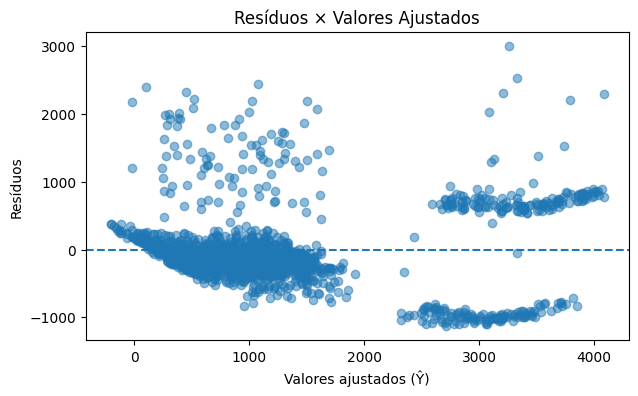

In [89]:
residuos = model_adjusted.resid
y_pred = model_adjusted.fittedvalues

plt.figure(figsize=(7, 4))

plt.scatter(y_pred, residuos, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel("Valores ajustados (Ŷ)")
plt.ylabel("Resíduos")
plt.title("Resíduos × Valores Ajustados")

plt.show()

# **Regressão Linear Multipla - Modelo final**

Parâmetros estimados:
[-1210.27693627  2381.13998446    25.78495073    32.18514025
    47.35023156]

Modelo estimado:
Ŷ = -1210.277 + 2381.140X₁ + 25.785X₂ + 32.185X₃ + 47.350X₄ 

R² = 0.750
R² ajustado = 0.749


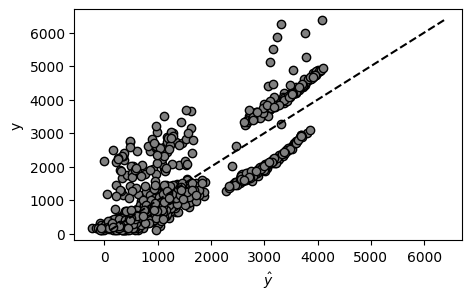

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:24:13   Log-Likelihood:                -10470.
No. Observations:                1338   AIC:                         2.095e+04
Df Residuals:                    1333   BIC:                         2.098e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1210.2769     94.198    -12.848      0.0

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera


# ENTRADA DOS DADOS

['Idade', 'Sexo', 'IMC', 'Qte_Filhos', 'Fumante', 'Região',
       'Custo_Saude', 'fumante_dummy', 'sexo_dummy', 'sudeste_dummy',
       'norte_dummy', 'nordeste_dummy']


# Variáveis explicativas
x1 = np.array(df['fumante_dummy'])
x2 = np.array(df['Idade'])
x3 = np.array(df['IMC'])
x4 = np.array(df['Qte_Filhos'])

# Variável resposta
y = np.array(df['Custo_Saude'])


# CRIA A COLUNA DO INTERCEPTO
# Coluna de 1's usada para estimar θ₀

x0 = np.ones(len(x1))

# CRIA A MATRIZ X

X = np.hstack((
    x0.reshape(-1, 1),
    x1.reshape(-1, 1),
    x2.reshape(-1, 1),
    x3.reshape(-1, 1),
    x4.reshape(-1, 1)
))

# AJUSTA O MODELO OLS

model = sm.OLS(y, X)

# .fit() estima os parâmetros
model_adjusted = model.fit()

# CALCULA OS VALORES ESTIMADOS

y_pred = model_adjusted.predict(X)

# MOSTRA OS PARÂMETROS

print("Parâmetros estimados:")
print(model_adjusted.params)

# MOSTRA O MODELO ESTIMADO

print("\nModelo estimado:")

print(
    f"Ŷ = {model_adjusted.params[0]:.3f} "
    f"+ {model_adjusted.params[1]:.3f}X₁ "
    f"+ {model_adjusted.params[2]:.3f}X₂ "
    f"+ {model_adjusted.params[3]:.3f}X₃ "
    f"+ {model_adjusted.params[4]:.3f}X₄ "
)

# R²:

print(f"\nR² = {model_adjusted.rsquared:.3f}")

# R² ajustado:

print(f"R² ajustado = {model_adjusted.rsquared_adj:.3f}")

# GRÁFICO: Y ESTIMADO × Y OBSERVADO

plt.figure(figsize=(5, 3))

plt.plot(
    y_pred,
    y,
    'o',
    color='gray',
    markersize=6,
    markerfacecolor='gray',
    markeredgecolor='black'
)

# Linha y = ŷ
xy = np.arange(
    np.min(y),
    np.max(y),
    0.1
)

plt.plot(
    xy,
    xy,
    color='black',
    linestyle='--'
)

plt.xlabel(r"$\hat{y}$")
plt.ylabel("y")

plt.show()

# RESUMO ESTATÍSTICO E DIAGNÓSTICOS DO MODELO

print(model_adjusted.summary())

# MULTICOLINEARIDADE — VIF

vif = []

for i in range(1, X.shape[1]):
    vif.append(
        variance_inflation_factor(X, i)
    )

print("\n--- Multicolinearidade (VIF) ---")

for i, valor in enumerate(vif, start=1):
    print(f"X{i}: VIF = {valor:.3f}")

# HOMOCEDASTICIDADE — TESTE DE BREUSCH-PAGAN

bp = het_breuschpagan(
    model_adjusted.resid,
    model_adjusted.model.exog
)

bp_lm_stat = bp[0]
bp_lm_pvalue = bp[1]

print("\n--- Homocedasticidade (Breusch-Pagan) ---")
print(f"Estatística LM: {bp_lm_stat:.3f}")
print(f"p-valor: {bp_lm_pvalue:.3f}")

#Dada a existência da heterocedasticidade, corrigindo o erro padrão calculado dos
#parâmetros para o erro padrão robusto, a fim de realizar inferências válidas

# HC3 = estimador de erro-padrão robusto à heterocedasticidade

model_robusto = model_adjusted.get_robustcov_results(
    cov_type='HC3',
    use_t=True
)

print("\n--- Inferência robusta à heterocedasticidade ---")

print("Coeficiente     Erro-padrão     t       p-valor")

for i in range(len(model_robusto.params)):

    coef = model_robusto.params[i]
    erro_padrao = model_robusto.bse[i]
    t = model_robusto.tvalues[i]
    p_valor = model_robusto.pvalues[i]

    print(
        f"{coef:10.3f}     "
        f"{erro_padrao:10.3f}     "
        f"{t:7.3f}     "
        f"{p_valor:.4f}"
    )

# IC de 95% para cada β

ic_robusto = model_robusto.conf_int(alpha=0.05)

print("\n--- Intervalo de confiança robusto (95%) ---")

for i in range(len(model_robusto.params)):

    coef = model_robusto.params[i]
    limite_inferior = ic_robusto[i, 0]
    limite_superior = ic_robusto[i, 1]

    print(
        f"β{i}: "
        f"estimativa = {coef:.3f} | "
        f"IC95% = [{limite_inferior:.3f}, "
        f"{limite_superior:.3f}]"
    )


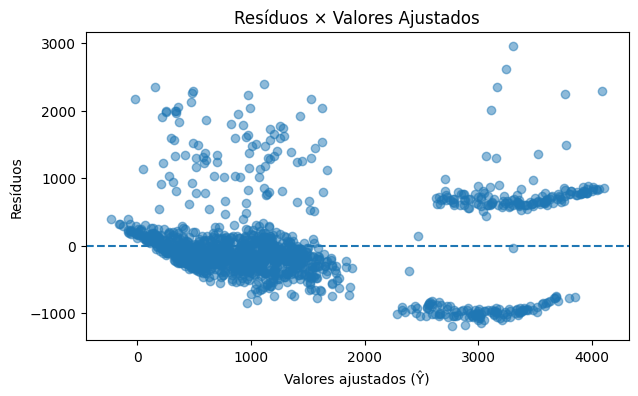

In [91]:
residuos = model_adjusted.resid
y_pred = model_adjusted.fittedvalues

plt.figure(figsize=(7, 4))

plt.scatter(y_pred, residuos, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel("Valores ajustados (Ŷ)")
plt.ylabel("Resíduos")
plt.title("Resíduos × Valores Ajustados")

plt.show()

In [92]:
print("Previsões negativas:", np.sum(y_pred < 0))
print("Percentual negativo:", np.mean(y_pred < 0) * 100)


Previsões negativas: 19
Percentual negativo: 1.4200298953662183


# **Intervalo de confiança - Qtd FiLhos, Idade e IMC**

Idade:


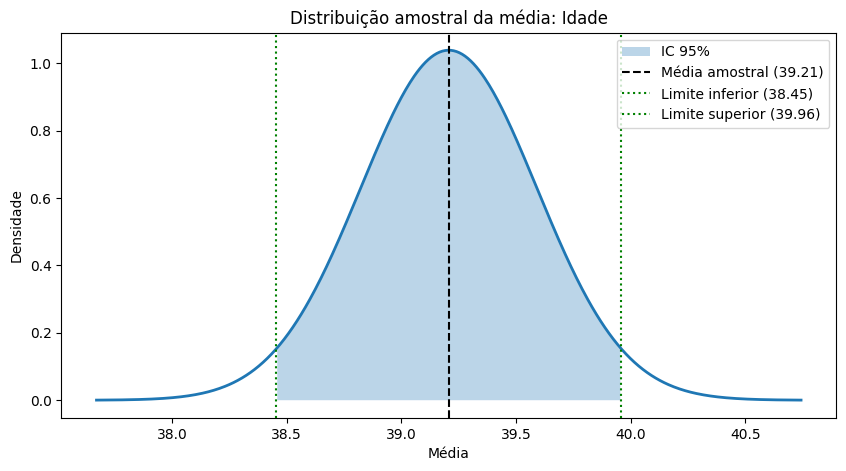


Resumo da amostra
Média amostral: 39.21
Tamanho da amostra: 1338
Desvio padrão amostral: 14.05

Intervalo de confiança (95%):
Limite inferior: 38.4542
Limite superior: 39.9599
IMC:


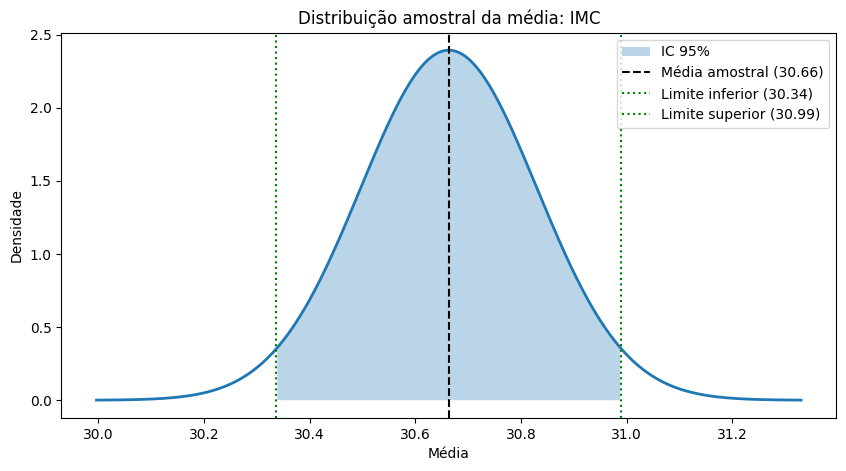


Resumo da amostra
Média amostral: 30.66
Tamanho da amostra: 1338
Desvio padrão amostral: 6.10

Intervalo de confiança (95%):
Limite inferior: 30.3366
Limite superior: 30.9902
Qtd de filhos:


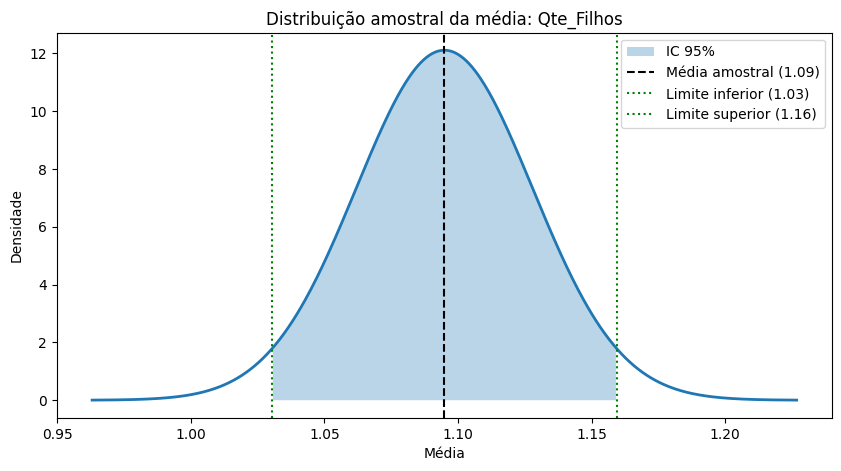


Resumo da amostra
Média amostral: 1.09
Tamanho da amostra: 1338
Desvio padrão amostral: 1.21

Intervalo de confiança (95%):
Limite inferior: 1.0303
Limite superior: 1.1595


In [93]:
import scipy.stats

def intervalo_de_confianca_conj_dados (X, confianca, sigma = -1, grafico = False):

  nome_coluna = X.name

  X = np.array(X)

  #criar função para calcular o desvio padrão amostral
  def S(X):
    s = 0
    for i in range (0,len(X)):
      s = s + (X[i] -np.mean(X))**2
    s = np.sqrt(s/(len(X)-1))
    return s

  Xs = np.mean(X)
  n = len(X)
  s = S(X)

  alpha = (1-confianca)/2
  z_alpha = abs(scipy.stats.norm.ppf(alpha))

  #se o desvio padrao é conhecido, utilizaremos a formula abaixo
  if(sigma != -1):
    IC1 = Xs - z_alpha*sigma/np.sqrt(n)
    IC2 = Xs + z_alpha*sigma/np.sqrt(n)

  # se o desvio padrão é desconhecido....
  else:
    #dependendo do tamanho da amostra....
    if(n >= 50): #usar dist normal
      IC1 = Xs - z_alpha*s/np.sqrt(n)
      IC2 = Xs + z_alpha*s/np.sqrt(n)
    else: #usar dist t
      t_alpha = abs(scipy.stats.t.ppf(alpha, n-1))
      IC1 = Xs - t_alpha*s/np.sqrt(n)
      IC2 = Xs + t_alpha*s/np.sqrt(n)


  if(grafico):

    # Calcula o erro padrão da média de acordo com o caso utilizado
    if(sigma != -1):

      # Sigma conhecido -> distribuição Normal
      erro_padrao = sigma/np.sqrt(n)

      # Intervalo de valores usado apenas para desenhar a curva
      x = np.linspace(Xs - 4*erro_padrao, Xs + 4*erro_padrao, 500)

      # Calcula a densidade da Normal em cada ponto do eixo x
      y = scipy.stats.norm.pdf(x, loc=Xs, scale=erro_padrao)

    else:

      # Sigma desconhecido -> usa o desvio padrão amostral
      erro_padrao = s/np.sqrt(n)

      if(n >= 50):

        # Amostras grandes: aproximação pela Normal
        x = np.linspace(Xs - 4*erro_padrao, Xs + 4*erro_padrao, 500)
        y = scipy.stats.norm.pdf(x, loc=Xs, scale=erro_padrao)

      else:

        # Amostras pequenas: distribuição t de Student
        x = np.linspace(Xs - 4*erro_padrao, Xs + 4*erro_padrao, 500)
        y = scipy.stats.t.pdf(x, df=n-1, loc=Xs, scale=erro_padrao)

    plt.figure(figsize=(10,5))

    # Curva da distribuição amostral
    plt.plot(x, y, linewidth=2)

    # Seleciona apenas a região compreendida pelo intervalo de confiança
    x_fill = x[(x >= IC1) & (x <= IC2)]

    # Calcula novamente a densidade apenas nessa região para preenchê-la
    if(sigma != -1):

      y_fill = scipy.stats.norm.pdf(
          x_fill,
          loc=Xs,
          scale=erro_padrao
      )

    else:

      if(n >= 50):

        y_fill = scipy.stats.norm.pdf(
            x_fill,
            loc=Xs,
            scale=erro_padrao
        )

      else:

        y_fill = scipy.stats.t.pdf(
            x_fill,
            df=n-1,
            loc=Xs,
            scale=erro_padrao
        )

    # Destaca a área correspondente ao intervalo de confiança
    plt.fill_between(
        x_fill,
        y_fill,
        alpha=0.3,
        label=f'IC {confianca*100:.0f}%'
    )

    # Média amostral
    plt.axvline(
        Xs,
        color='black',
        linestyle='--',
        label=f'Média amostral ({Xs:.2f})'
    )

    # Limites inferior e superior do intervalo
    plt.axvline(
        IC1,
        color='green',
        linestyle=':',
        label=f'Limite inferior ({IC1:.2f})'
    )

    plt.axvline(
        IC2,
        color='green',
        linestyle=':',
        label=f'Limite superior ({IC2:.2f})'
    )


    plt.title(f'Distribuição amostral da média: {nome_coluna}')
    plt.xlabel('Média')
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

  print(f'\nResumo da amostra')
  print(f'Média amostral: {Xs:.2f}')
  print(f'Tamanho da amostra: {n}')
  print(f'Desvio padrão amostral: {s:.2f}')

  if(sigma != -1):
      print(f'Desvio padrão populacional informado: {sigma:.2f}')

  print(f'\nIntervalo de confiança ({confianca*100:.0f}%):')
  print(f'Limite inferior: {IC1:.4f}')
  print(f'Limite superior: {IC2:.4f}')

  return IC1, IC2

dados = df['Idade']

print('Idade:')

IC = intervalo_de_confianca_conj_dados(
      dados,
      confianca=0.95,
      grafico=True
  )

dados = df['IMC']

print('IMC:')

IC = intervalo_de_confianca_conj_dados(
      dados,
      confianca=0.95,
      grafico=True
  )

dados = df['Qte_Filhos']

print('Qtd de filhos:')

IC = intervalo_de_confianca_conj_dados(
      dados,
      confianca=0.95,
      grafico=True
  )



# **Intervalo de confiança - Proporção de Fumantes**

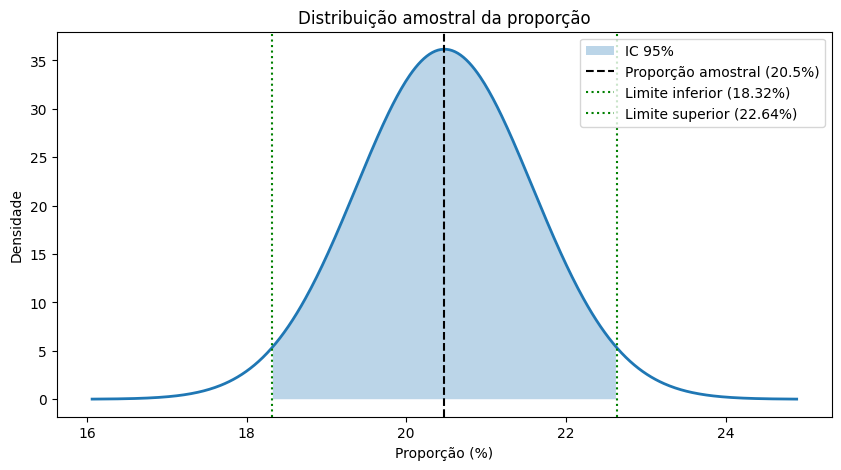

IC de 95%:18.32%, 22.64%


In [94]:
import scipy.stats as st

def intervalo_de_confianca_proporcao(p_hat, n, confianca, grafico=False):

    alpha = (1 - confianca) / 2

    z_alpha = abs(st.norm.ppf(alpha))

    # Erro padrão da proporção
    erro_padrao = np.sqrt(p_hat * (1 - p_hat) / n)

    IC1 = p_hat - z_alpha * erro_padrao
    IC2 = p_hat + z_alpha * erro_padrao

    if grafico:

        x = np.linspace(
            p_hat - 4 * erro_padrao,
            p_hat + 4 * erro_padrao,
            500
        )

        y = st.norm.pdf(x, loc=p_hat, scale=erro_padrao)

        plt.figure(figsize=(10,5))

        # Curva da distribuição amostral
        plt.plot(x*100, y, linewidth=2)

        # Área do IC
        x_fill = x[(x >= IC1) & (x <= IC2)]
        y_fill = st.norm.pdf(x_fill, loc=p_hat, scale=erro_padrao)

        plt.fill_between(x_fill*100, y_fill, alpha=0.3, label='IC 95%')

        # Estimativa pontual
        plt.axvline(
            p_hat*100,
            color='black',
            linestyle='--',
            label=f'Proporção amostral ({p_hat*100:.1f}%)'
        )

        # Limites do IC
        plt.axvline(
        IC1 * 100,
        color='green',
        linestyle=':',
        label=f'Limite inferior ({IC1*100:.2f}%)'
    )

        plt.axvline(
        IC2 * 100,
        color='green',
        linestyle=':',
        label=f'Limite superior ({IC2*100:.2f}%)'
    )

        plt.title('Distribuição amostral da proporção')
        plt.xlabel('Proporção (%)')
        plt.ylabel('Densidade')
        plt.legend()
        plt.show()

    return IC1, IC2

prop_fumantes = df['fumante_dummy'].sum()/len(df)
n = len(df)


IC = intervalo_de_confianca_proporcao(
    prop_fumantes,
    n,
    0.95,
    grafico=True
)

li, ls = IC
print(f'IC de 95%:{li*100:.2f}%, {ls*100:.2f}%')

# **Intervalo de Confiança - Proporção de Obesos**


Quantidade de colaboradores obesos na amostra: 707
Tamanho da amostra: 1338
Proporção amostral de obesos: 52.84%


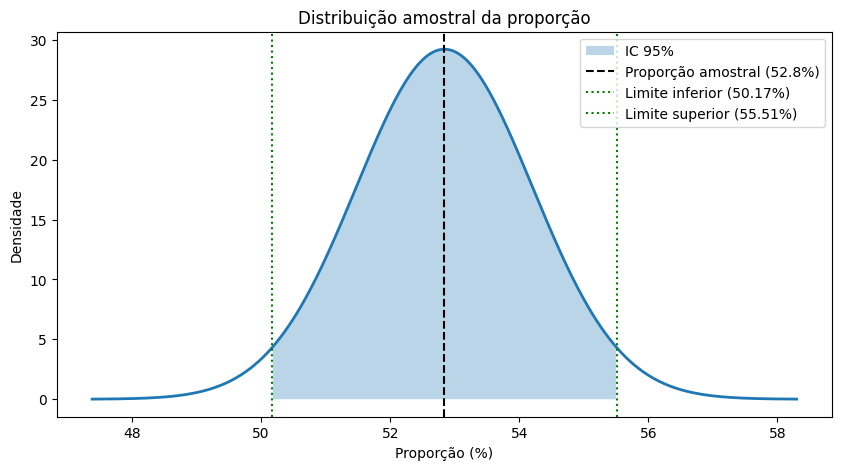

IC de 95% para a proporção de obesos: 50.17% a 55.51%


In [95]:
# 1 = IMC >= 30 (obeso)
# 0 = IMC < 30
df['obeso_dummy'] = (df['IMC'] >= 30).astype(int)


# Proporção amostral de obesos
prop_obesos = df['obeso_dummy'].sum() / len(df)

n = len(df)


print(f'Quantidade de colaboradores obesos na amostra: {df["obeso_dummy"].sum()}')
print(f'Tamanho da amostra: {n}')
print(f'Proporção amostral de obesos: {prop_obesos*100:.2f}%')


IC = intervalo_de_confianca_proporcao(
    prop_obesos,
    n,
    0.95,
    grafico=True
)


li, ls = IC

print(
    f'IC de 95% para a proporção de obesos: '
    f'{li*100:.2f}% a {ls*100:.2f}%')